# BNN Comparison: Laplace Approximation vs Bayesian-Torch (Flipout)

This notebook compares two Bayesian Neural Network approaches on a **sinusoidal regression** task:

| Method | Type | Posterior | Inference |
|--------|------|-----------|-----------|
| **Laplace-Torch** | Post-hoc approximation | N(w_MAP, H⁻¹ via full Hessian) | GLM predictive (closed-form) |
| **Bayesian-Torch** | SVI during training | Learned variational posterior (Flipout) | MC sampling (100 samples) |

Both methods share the same MAP-trained network and dataset.


## 1. Imports & Setup


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from torch.utils.data import DataLoader, TensorDataset
from scipy.stats import norm

from laplace import Laplace
from bayesian_torch.models.dnn_to_bnn import dnn_to_bnn, get_kl_loss

np.random.seed(711)
torch.manual_seed(711)
print("All imports successful!")






All imports successful!


## 2. Data: Sinusoidal Regression

Both methods use the same sinusoidal dataset with known noise level σ=0.3.


In [2]:
def get_sinusoid_data(n_train=150, sigma_noise=0.3):
    X_train = (torch.rand(n_train) * 8).unsqueeze(-1)
    y_train = torch.sin(X_train) + torch.randn_like(X_train) * sigma_noise
    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=150, shuffle=True)
    X_test = torch.linspace(-5, 13, 500).unsqueeze(-1)
    return X_train, y_train, train_loader, X_test

sigma_noise = 0.3
X_train, y_train, train_loader, X_test = get_sinusoid_data(sigma_noise=sigma_noise)

X_train_np = X_train.flatten().cpu().numpy()
y_train_np = y_train.flatten().cpu().numpy()
x_test_np = X_test.flatten().cpu().numpy()
print(f"Train: {X_train.shape}, Test: {X_test.shape}")






Train: torch.Size([150, 1]), Test: torch.Size([500, 1])


## 3. Shared Model Architecture

Both methods use the same network: `Linear(1,50) → Tanh → Linear(50,1)`


In [3]:
def get_model():
    torch.manual_seed(711)
    return nn.Sequential(
        nn.Linear(1, 50),
        nn.Tanh(),
        nn.Linear(50, 1)
    )

n_epochs_map = 1000
n_epochs_bnn = 1000
n_epochs_marglik = 1000
num_mc_samples = 100

model_map = get_model()
print(f"Model parameters: {sum(p.numel() for p in model_map.parameters())}")






Model parameters: 151


## 4. Phase 1: MAP Training

Both methods start from the same MAP-trained deterministic network.


In [4]:
print("Training MAP model...")
criterion = nn.MSELoss()
optimizer = optim.Adam(model_map.parameters(), lr=1e-2)

map_losses = []
for epoch in range(n_epochs_map):
    epoch_loss = 0.0
    for X, y in train_loader:
        optimizer.zero_grad()
        loss = criterion(model_map(X), y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    epoch_loss /= len(train_loader)
    map_losses.append(epoch_loss)
    if (epoch + 1) % 200 == 0:
        print(f"  Epoch {epoch+1}/{n_epochs_map}, Loss: {epoch_loss:.6f}")

model_map.eval()
with torch.no_grad():
    f_map = model_map(X_test).squeeze().cpu().numpy()
print(f"MAP complete. Final loss: {map_losses[-1]:.6f}")






Training MAP model...
  Epoch 200/1000, Loss: 0.078239
  Epoch 400/1000, Loss: 0.076034
  Epoch 600/1000, Loss: 0.074960
  Epoch 800/1000, Loss: 0.074435
  Epoch 1000/1000, Loss: 0.074069
MAP complete. Final loss: 0.074069


## 5. Method A: Laplace Approximation

- Take MAP weights, approximate posterior N(w_MAP, H⁻¹) with full Hessian
- Optimize prior precision and noise std via marginal likelihood
- GLM predictive for closed-form variance


In [5]:
print("Fitting Laplace approximation...")
la = Laplace(model_map, "regression", subset_of_weights="all", hessian_structure="full")
la.fit(train_loader)

print("Optimizing hyperparameters via marginal likelihood...")
log_prior = torch.ones(1, requires_grad=True)
log_sigma = torch.ones(1, requires_grad=True)
hyper_optimizer = torch.optim.Adam([log_prior, log_sigma], lr=1e-1)

marglik_values = []
for i in range(n_epochs_marglik):
    hyper_optimizer.zero_grad()
    neg_marglik = -la.log_marginal_likelihood(log_prior.exp(), log_sigma.exp())
    neg_marglik.backward()
    hyper_optimizer.step()
    marglik_values.append(-neg_marglik.item())
    if (i + 1) % 200 == 0:
        print(f"  Epoch {i+1}/{n_epochs_marglik}, MargLik: {-neg_marglik.item():.4f}")

print(f"Learned sigma_noise: {la.sigma_noise.item():.4f}")
print(f"Learned prior precision: {la.prior_precision.item():.4f}")

f_mu_la, f_var_la = la(X_test)
f_mu_la = f_mu_la.squeeze().detach().cpu().numpy()
f_sigma_la = f_var_la.squeeze().sqrt().detach().cpu().numpy()
pred_std_la = np.sqrt(f_sigma_la**2 + la.sigma_noise.item()**2)
print(f"Laplace epistemic sigma: {f_sigma_la.mean():.4f}")






Fitting Laplace approximation...
Optimizing hyperparameters via marginal likelihood...
  Epoch 200/1000, MargLik: -58.9758
  Epoch 400/1000, MargLik: -58.9803
  Epoch 600/1000, MargLik: -58.9921
  Epoch 800/1000, MargLik: -58.9881
  Epoch 1000/1000, MargLik: -59.0022
Learned sigma_noise: 0.2817
Learned prior precision: 0.1004
Laplace epistemic sigma: 1.7089


## 6. Method B: Bayesian-Torch (Flipout + MOPED + SVI)

- Copy MAP model, convert to BNN with Flipout layers
- MOPED: initialize posterior mean = MAP weights
- ELBO fine-tuning: MSE + KL/batch_size
- MC sampling (100 passes) for predictive distribution


In [6]:
print("Converting to Bayesian-Torch (Flipout + MOPED)...")
bnn_prior_parameters = {
    "prior_mu": 0.0,
    "prior_sigma": 1.0,
    "posterior_mu_init": 0.0,
    "posterior_rho_init": -3.0,
    "type": "Flipout",
    "moped_enable": True,
    "moped_delta": 0.5,
}

model_bnn = get_model()
model_bnn.load_state_dict(model_map.state_dict())
dnn_to_bnn(model_bnn, bnn_prior_parameters)

optimizer = optim.Adam(model_bnn.parameters(), lr=1e-3)
bnn_losses = []
kl_losses = []

print("Fine-tuning BNN with ELBO...")
for epoch in range(n_epochs_bnn):
    epoch_loss = 0.0
    epoch_kl = 0.0
    for X, y in train_loader:
        optimizer.zero_grad()
        output = model_bnn(X)
        kl = get_kl_loss(model_bnn)
        mse = criterion(output, y)
        loss = mse + kl / X.size(0)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        epoch_kl += kl.item()
    epoch_loss /= len(train_loader)
    epoch_kl /= len(train_loader)
    bnn_losses.append(epoch_loss)
    kl_losses.append(epoch_kl)
    if (epoch + 1) % 200 == 0:
        print(f"  Epoch {epoch+1}/{n_epochs_bnn}, ELBO: {epoch_loss:.6f}, KL: {epoch_kl:.6f}")

print(f"BNN complete. Final ELBO: {bnn_losses[-1]:.6f}")

model_bnn.eval()
with torch.no_grad():
    mc_preds = torch.stack([model_bnn(X_test) for _ in range(num_mc_samples)])

f_mu_bnn = mc_preds.mean(dim=0).squeeze().cpu().numpy()
f_sigma_bnn = mc_preds.std(dim=0).squeeze().cpu().numpy()
pred_std_bnn = np.sqrt(f_sigma_bnn**2 + sigma_noise**2)
print(f"Bayesian-Torch epistemic sigma: {f_sigma_bnn.mean():.4f}")






Converting to Bayesian-Torch (Flipout + MOPED)...
Fine-tuning BNN with ELBO...
  Epoch 200/1000, ELBO: 2.153100, KL: 8.812879
  Epoch 400/1000, ELBO: 2.835639, KL: 8.698133
  Epoch 600/1000, ELBO: 1.670689, KL: 8.622345
  Epoch 800/1000, ELBO: 1.231731, KL: 8.545569
  Epoch 1000/1000, ELBO: 0.856697, KL: 8.460295
BNN complete. Final ELBO: 0.856697
Bayesian-Torch epistemic sigma: 0.9714


## 7. Evaluation Metrics

- **RMSE**: Root Mean Squared Error (point prediction accuracy, lower = better)
- **NLL**: Negative Log-Likelihood (predictive distribution quality, lower = better)
- **Calibration Error**: Uncertainty calibration quality (lower = better)


In [7]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

def neg_log_likelihood(y_true, y_pred_mean, y_pred_std):
    n = len(y_true)
    ll = 0.5 * np.sum(np.log(2 * np.pi * y_pred_std**2) + (y_true - y_pred_mean)**2 / y_pred_std**2)
    return ll / n

def cal_error(y_true, y_pred_mean, y_pred_std, n_bins=20):
    z = np.abs(y_true - y_pred_mean) / y_pred_std
    conf = np.linspace(0.05, 0.95, n_bins)
    exp, obs = [], []
    for c in conf:
        t = norm.ppf((1 + c) / 2)
        exp.append(c)
        obs.append(np.mean(z <= t))
    return np.mean(np.abs(np.array(exp) - np.array(obs)))

# Noisy test targets
rng = np.random.RandomState(711)
y_test = np.sin(x_test_np) + rng.randn(len(x_test_np)) * sigma_noise

print("="*70)
print("COMPARISON RESULTS")
print("="*70)
print(f"{'Method':20s} {'RMSE':8s} {'NLL':8s} {'Cal Err':8s} {'Epistemic':10s}")
print("-"*70)

for name, pm, ps, epi in [
    ("Laplace-Torch", f_mu_la, pred_std_la, f_sigma_la),
    ("Bayesian-Torch", f_mu_bnn, pred_std_bnn, f_sigma_bnn),
    ("MAP", f_map, None, None),
]:
    r = rmse(y_test, pm)
    n = neg_log_likelihood(y_test, pm, ps) if ps is not None else float("nan")
    c = cal_error(y_test, pm, ps) if ps is not None else float("nan")
    e = epi.mean() if epi is not None else float("nan")
    print(f"{name:20s} {r:.4f}    {n:.4f}   {c:.4f}    {e:.4f}")
print("="*70)






COMPARISON RESULTS
Method               RMSE     NLL      Cal Err  Epistemic 
----------------------------------------------------------------------
Laplace-Torch        1.4151    1.4995   0.0579    1.7089
Bayesian-Torch       1.0942    1.4854   0.0182    0.9714
MAP                  1.4151    nan   nan    nan


## 8. Comparison Visualizations


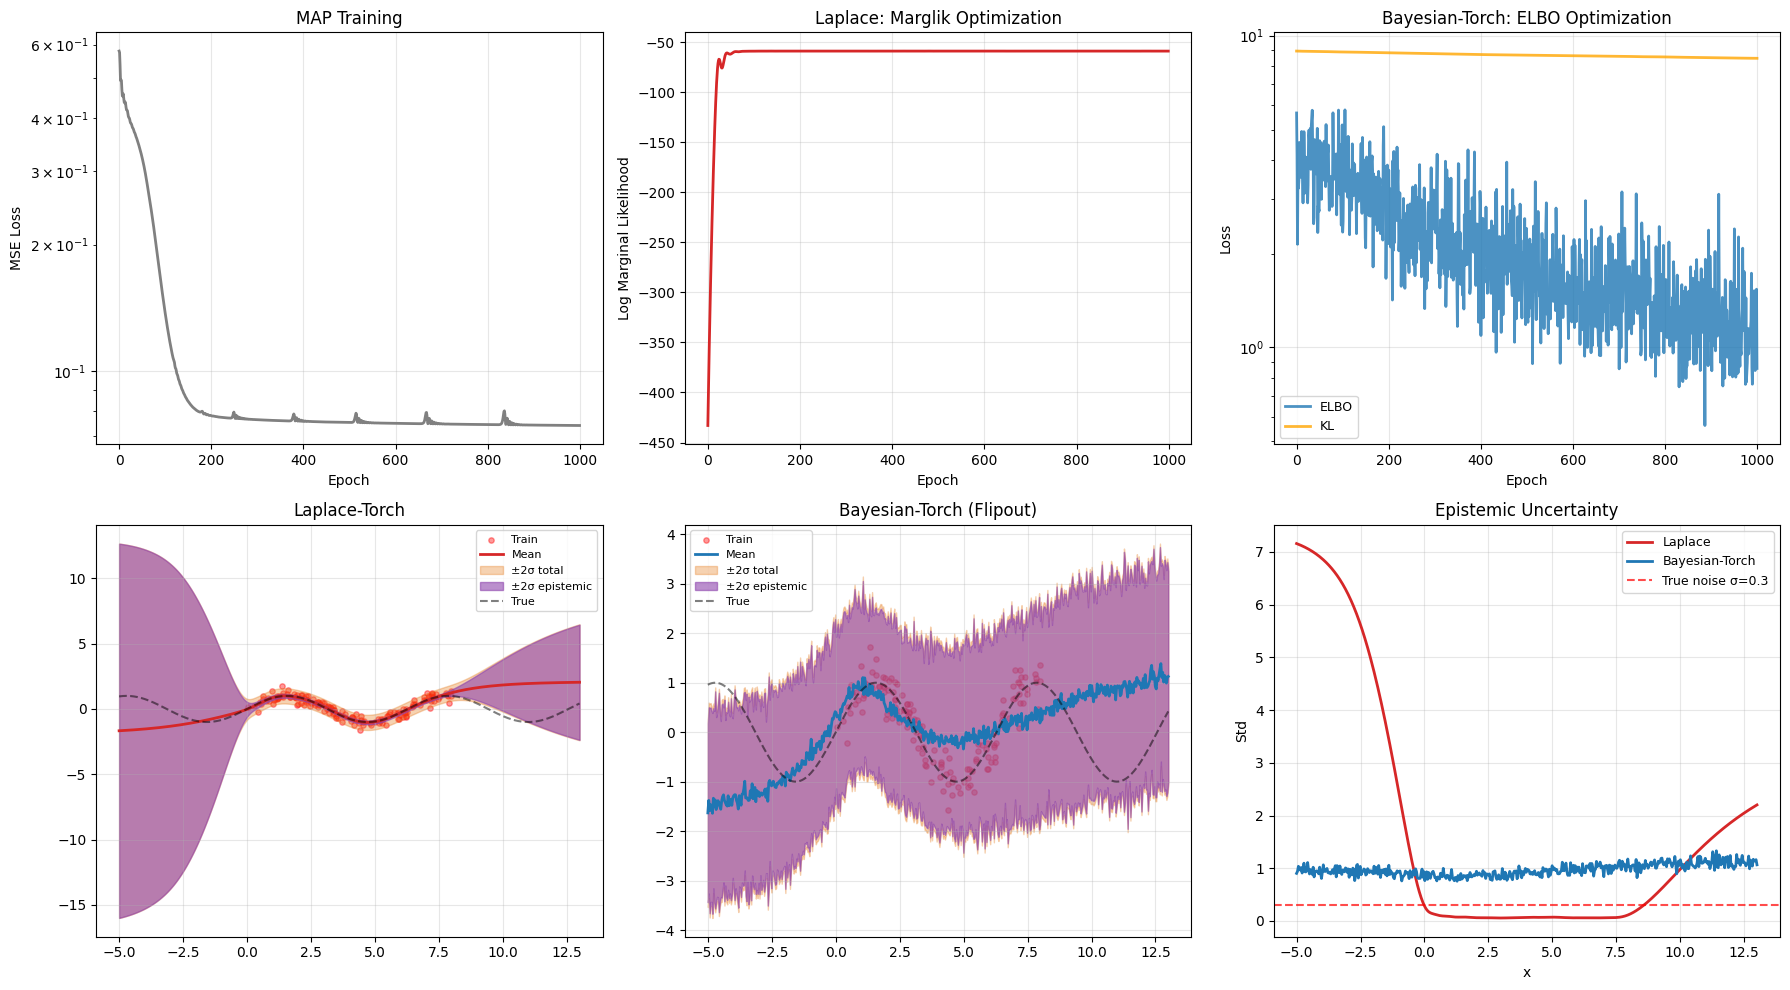

In [8]:
la_color = "#d62728"
bt_color = "#1f77b4"

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 0: Training curves
axes[0, 0].plot(map_losses, color="gray", linewidth=2)
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("MSE Loss")
axes[0, 0].set_title("MAP Training")
axes[0, 0].set_yscale("log")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(marglik_values, color=la_color, linewidth=2)
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Log Marginal Likelihood")
axes[0, 1].set_title("Laplace: Marglik Optimization")
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].plot(bnn_losses, color=bt_color, linewidth=2, label="ELBO", alpha=0.8)
axes[0, 2].plot(kl_losses, color="orange", linewidth=2, label="KL", alpha=0.8)
axes[0, 2].set_xlabel("Epoch")
axes[0, 2].set_ylabel("Loss")
axes[0, 2].set_title("Bayesian-Torch: ELBO Optimization")
axes[0, 2].set_yscale("log")
axes[0, 2].legend(fontsize=9)
axes[0, 2].grid(True, alpha=0.3)

# Row 1: Predictions
axes[1, 0].scatter(X_train_np, y_train_np, color="red", s=15, alpha=0.4, label="Train")
axes[1, 0].plot(x_test_np, f_mu_la, color=la_color, linewidth=2, label="Mean")
axes[1, 0].fill_between(x_test_np, f_mu_la-2*pred_std_la, f_mu_la+2*pred_std_la, alpha=0.35, color="#e67e22", label="±2σ total")
axes[1, 0].fill_between(x_test_np, f_mu_la-2*f_sigma_la, f_mu_la+2*f_sigma_la, alpha=0.6, color="#8e44ad", label="±2σ epistemic")
axes[1, 0].plot(x_test_np, np.sin(x_test_np), "k--", alpha=0.5, label="True")
axes[1, 0].set_title("Laplace-Torch")
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(X_train_np, y_train_np, color="red", s=15, alpha=0.4, label="Train")
axes[1, 1].plot(x_test_np, f_mu_bnn, color=bt_color, linewidth=2, label="Mean")
axes[1, 1].fill_between(x_test_np, f_mu_bnn-2*pred_std_bnn, f_mu_bnn+2*pred_std_bnn, alpha=0.35, color="#e67e22", label="±2σ total")
axes[1, 1].fill_between(x_test_np, f_mu_bnn-2*f_sigma_bnn, f_mu_bnn+2*f_sigma_bnn, alpha=0.6, color="#8e44ad", label="±2σ epistemic")
axes[1, 1].plot(x_test_np, np.sin(x_test_np), "k--", alpha=0.5, label="True")
axes[1, 1].set_title("Bayesian-Torch (Flipout)")
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].plot(x_test_np, f_sigma_la, color=la_color, linewidth=2, label="Laplace")
axes[1, 2].plot(x_test_np, f_sigma_bnn, color=bt_color, linewidth=2, label="Bayesian-Torch")
axes[1, 2].axhline(y=sigma_noise, color="red", ls="--", alpha=0.7, label=f"True noise σ={sigma_noise}")
axes[1, 2].set_xlabel("x")
axes[1, 2].set_ylabel("Std")
axes[1, 2].set_title("Epistemic Uncertainty")
axes[1, 2].legend(fontsize=9)
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()






## 9. Uncertainty Calibration


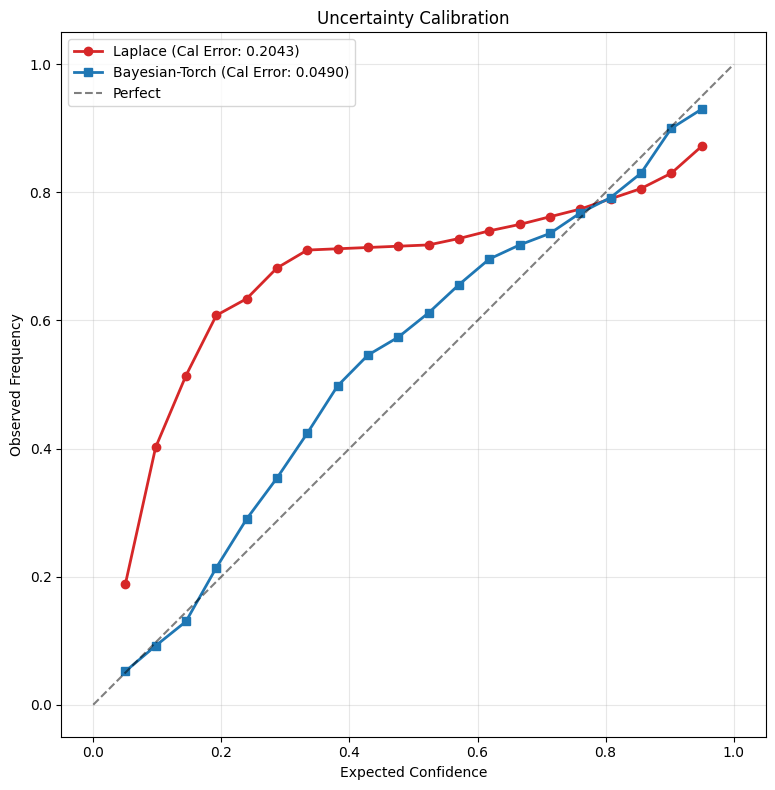

In [9]:
def calibration_curve(y_true, y_pred_mean, y_pred_std, n_bins=20):
    z = np.abs(y_true - y_pred_mean) / y_pred_std
    conf = np.linspace(0.05, 0.95, n_bins)
    exp, obs = [], []
    for c in conf:
        t = norm.ppf((1 + c) / 2)
        exp.append(c)
        obs.append(np.mean(z <= t))
    return exp, obs

y_true_sin = np.sin(x_test_np)
exp_la, obs_la = calibration_curve(y_true_sin, f_mu_la, pred_std_la)
cal_la = np.mean(np.abs(np.array(exp_la) - np.array(obs_la)))
exp_bt, obs_bt = calibration_curve(y_true_sin, f_mu_bnn, pred_std_bnn)
cal_bt = np.mean(np.abs(np.array(exp_bt) - np.array(obs_bt)))

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(exp_la, obs_la, "o-", color=la_color, lw=2, label=f"Laplace (Cal Error: {cal_la:.4f})")
ax.plot(exp_bt, obs_bt, "s-", color=bt_color, lw=2, label=f"Bayesian-Torch (Cal Error: {cal_bt:.4f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfect")
ax.set_xlabel("Expected Confidence")
ax.set_ylabel("Observed Frequency")
ax.set_title("Uncertainty Calibration")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()






## 10. Summary

| Metric | Laplace-Torch | Bayesian-Torch |
|--------|:------------:|:--------------:|
| **Type** | Post-hoc Laplace | SVI (Flipout) |
| **Inference** | Closed-form (GLM) | MC sampling |
| **Uncertainty** | Local Gaussian approx | Learned variational |
| **Speed** | Fast (one Hessian fit) | Slower (full training) |
| **KL term** | Marglik optimization | ELBO regularization |


In [10]:
print("="*70)
print("BNN COMPARISON SUMMARY (Sinusoidal Regression)")
print("="*70)
print(f"{'Metric':20s} {'Laplace-Torch':15s} {'Bayesian-Torch':15s}")
print("-"*50)
for metric, la_val, bt_val in [
    ("RMSE", rmse(y_test, f_mu_la), rmse(y_test, f_mu_bnn)),
    ("NLL", neg_log_likelihood(y_test, f_mu_la, pred_std_la), neg_log_likelihood(y_test, f_mu_bnn, pred_std_bnn)),
    ("Cal Error", cal_error(y_test, f_mu_la, pred_std_la), cal_error(y_test, f_mu_bnn, pred_std_bnn)),
    ("Epistemic mean", f_sigma_la.mean(), f_sigma_bnn.mean()),
]:
    print(f"{metric:20s} {la_val:.4f}         {bt_val:.4f}")
print("-"*50)
print(f"True noise sigma: {sigma_noise}")
print(f"Laplace learned sigma_noise: {la.sigma_noise.item():.4f}")
print("="*70)






BNN COMPARISON SUMMARY (Sinusoidal Regression)
Metric               Laplace-Torch   Bayesian-Torch 
--------------------------------------------------
RMSE                 1.4151         1.0942
NLL                  1.4995         1.4854
Cal Error            0.0579         0.0182
Epistemic mean       1.7089         0.9714
--------------------------------------------------
True noise sigma: 0.3
Laplace learned sigma_noise: 0.2817
